In [1]:
from typing import List , TypedDict , Literal
from pydantic import BaseModel , Field

from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_cerebras import ChatCerebras
from langchain_groq import ChatGroq

from langchain_huggingface import HuggingFaceEmbeddings
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langgraph.graph import StateGraph , START , END
from langchain_core.documents import Document

from dotenv import load_dotenv

In [2]:
load_dotenv()

True

In [3]:
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document

from langchain_community.document_loaders import PyPDFLoader

/tmp/ipykernel_23665/3129910071.py:4: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader


In [ ]:
docs=(
    PyPDFLoader("/content/Company_Policies.pdf").load()+
    PyPDFLoader("/content/Company_Profile.pdf").load()+
    PyPDFLoader("/content/Product_and_Pricing.pdf").load()
)

In [ ]:
chunks = RecursiveCharacterTextSplitter(chunk_size=600,chunk_overlap=150).split_documents(docs)

In [3]:
embeddings = HuggingFaceEmbeddings(model_name="BAAI/bge-large-en-v1.5")

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

In [4]:
from qdrant_client import QdrantClient
from langchain_qdrant import QdrantVectorStore
from qdrant_client.http.models import Distance, VectorParams

client=QdrantClient(path="./company_db")
# client.create_collection(
#     collection_name="company_db",
#     vectors_config=VectorParams(size=1024, distance=Distance.COSINE),
# )
vector_store=QdrantVectorStore(
    client=client,
    collection_name="company_db",
    embedding=embeddings)

In [ ]:
# vector_store.add_documents(chunks)

In [ ]:
# !zip -r company_db.zip /content/company_db/
# from google.colab import files
# files.download("company_db.zip")

In [5]:
retriever = vector_store.as_retriever(search_kwargs={"k":4})

In [6]:
llm_cerebras=ChatCerebras(model="gpt-oss-120b",temperature=0)
llm_gemini=ChatGoogleGenerativeAI(model="gemini-2.5-flash-lite",temperature=0)
llm_groq=ChatGroq(model="openai/gpt-oss-120b",temperature=0)

In [40]:
class RagState(TypedDict):
  query:str
  need_retrieval:bool

  docs: List[Document]
  relevant_docs: List[Document]

  context:str
  answer:str

  is_support:Literal['fully_supported','partially_supported','no_support']
  evidence:List[str]

  retries:int

  is_useful:bool
  use_reason:str


  retrieval_query:str
  rewrite_tries:int

In [8]:
class RetrieveDecision(BaseModel):
  should_retrieve:bool=Field(description="True if external documents are needed to answer reliably, else False.")

In [41]:
def decide_retrieval(state:RagState):
  chat_prompt= ChatPromptTemplate.from_messages([
      ('system',
       "You decide whether retrieval is needed.\n"
        "Guidelines:\n"
        "- should_retrieve=True if answering requires specific facts, citations, or info likely not in the model.\n"
        "- should_retrieve=False for general explanations, definitions, or reasoning that doesn't need sources.\n"
        "- If unsure, choose True."),
      ('human',"Question: {query}")
  ])
  chain = chat_prompt | llm_groq.with_structured_output(RetrieveDecision) # groq 1
  result=chain.invoke({'query':state['query']})
  return {'need_retrieval':result.should_retrieve}

def generate_direct(state:RagState):
  direct_generation_prompt = ChatPromptTemplate.from_messages(
    [
      (
          "system",
          "Answer the question using only your general knowledge.\n"
          "Do NOT assume access to external documents.\n"
          "If you are unsure or the answer requires specific sources, say:\n"
          "'I don't know based on my general knowledge.'"
      ),
      ("human", "{query}"),
    ]
  )
  chain=direct_generation_prompt | llm_cerebras # cerebras 1
  answer=chain.invoke(state['query'])
  return {'answer':answer.content}

def retrieve(state:RagState):
  q=state.get('retrieval_query') or state.get('query')
  return {"docs": retriever.invoke(q)}

In [10]:
def to_retrieve(state:RagState)->Literal['retrieve','generate_direct']:
  if state['need_retrieval']:
    return "retrieve"
  return "generate_direct"

In [11]:
class RelevanceDecision(BaseModel):
  is_relevant: bool = Field(
    ...,
    description="True if the document helps answer the question, else False."
  )


def is_relevant(state:RagState):
  chat_prompt=ChatPromptTemplate.from_messages([
      ("system",
        "You are judging document relevance.\n"
        "A document is relevant if it contains information useful for answering the question."),
      ("human","Question:\n{question}\n\nDocument:\n{document}")
  ])
  chain=chat_prompt | llm_groq.with_structured_output(RelevanceDecision) #groq 2
  relevant_docs:List[Document]=[]
  for doc in state['docs']:
    result=chain.invoke({
        'question':state['query'],
        'document':doc
    })
    if result.is_relevant:
      relevant_docs.append(doc)
  return {'relevant_docs':relevant_docs}


In [12]:
def generate_from_context(state:RagState):
  chat_prompt=ChatPromptTemplate.from_messages([
      ("system",
        "You are a business RAG assistant.\n"
        "Answer the user's question using ONLY the provided context.\n"
        "If the context does not contain enough information, say:\n"
        "'No relevant document found.'\n"
        "Do not use outside knowledge.\n"),
      ("human",
        "Question:\n{question}\n\n"
        "Context:\n{context}\n")
  ])

  context="\n\n".join([doc.page_content for doc in state['relevant_docs']])
  if not context:
    return {'answer':"No relevant document found.","context": ""}

  chain= chat_prompt | llm_cerebras # cerebras 2
  result=chain.invoke({
      'context':context,
      'question':state['query']
  })
  return {'answer':result.content,'context':context}


In [13]:
def no_relevant_docs(state:RagState): # in future to search on web(rewrite query and then do web searh and return to is_relevant)
  return {'answer':"No relevant document found.","context":""}


def route_after_relevance(state:RagState)->Literal['generate_from_context','no_relevant_docs']:
  if state.get("relevant_docs") and len(state["relevant_docs"]) > 0:
    return "generate_from_context"
  return "no_relevant_docs"

In [14]:
class IsSUPDecision(BaseModel):
  is_support:Literal['fully_supported','partially_supported','no_support']
  evidence:List[str]=Field(default_factory=list)

def is_sup(state:RagState):
  chat_prompt=ChatPromptTemplate([
      (
        "system",
        "You are verifying whether the ANSWER is supported by the CONTEXT.\n"
        "Return JSON with keys: issup, evidence.\n"
        "issup must be one of: fully_supported, partially_supported, no_support.\n\n"
        "How to decide issup:\n"
        "- fully_supported:\n"
        "  Every meaningful claim is explicitly supported by CONTEXT, and the ANSWER does NOT introduce\n"
        "  any qualitative/interpretive words that are not present in CONTEXT.\n"
        "  (Examples of disallowed words unless present in CONTEXT: culture, generous, robust, designed to,\n"
        "  supports professional development, best-in-class, employee-first, etc.)\n\n"
        "- partially_supported:\n"
        "  The core facts are supported, BUT the ANSWER includes ANY abstraction, interpretation, or qualitative\n"
        "  phrasing not explicitly stated in CONTEXT (e.g., calling policies 'culture', saying leave is 'generous',\n"
        "  or inferring outcomes like 'supports professional development').\n\n"
        "- no_support:\n"
        "  The key claims are not supported by CONTEXT.\n\n"
        "Rules:\n"
        "- Be strict: if you see ANY unsupported qualitative/interpretive phrasing, choose partially_supported.\n"
        "- If the answer is mostly unrelated to the question or unsupported, choose no_support.\n"
        "- Evidence: include up to 3 short direct quotes from CONTEXT that support the supported parts.\n"
        "- Do not use outside knowledge."
      ),
      (
        "human",
        "Question:\n{query}\n\n"
        "Answer:\n{answer}\n\n"
        "Context:\n{context}\n"
      )
  ])
  chain=chat_prompt | llm_cerebras.with_structured_output(IsSUPDecision) # cerebras 3
  result=chain.invoke({'query':state['query'],'answer':state['answer'],'context':state['context']})
  return {'is_support':result.is_support,'evidence':result.evidence}


MAX_RETRIES = 10

def route_after_issup(state: RagState) -> Literal["accept_answer", "revise_answer"]:
  # accept if fully supported
  if state.get("is_support") == "fully_supported":
    return "accept_answer"

  # stop if we've already tried enough
  if state.get("retries", 0) >= MAX_RETRIES:
    return "accept_answer"   # or return a "give_up" node if you want

  # otherwise revise again
  return "revise_answer"


In [15]:
def accept_answer(state: RagState):
    return {}  # keep answer as-is

In [16]:
from langchain_core.runnables import chain
def revise_answer(state: RagState):
    # revise answer
    chat_prompt = ChatPromptTemplate.from_messages(
        [
            (
              "system",
              "You are a STRICT reviser.\n\n"
              "You must output based on the following format:\n\n"
              "FORMAT (quote-only answer):\n"
              "- <direct quote from the CONTEXT>\n"
              "- <direct quote from the CONTEXT>\n\n"
              "Rules:\n"
              "- Use ONLY the CONTEXT.\n"
              "- Do NOT add any new words besides bullet dashes and the quotes themselves.\n"
              "- Do NOT explain anything.\n"
              "- Do NOT say 'context', 'not mentioned', 'does not mention', 'not provided', etc.\n"
              ),
            (
              "human",
              "Question:\n{question}\n\n"
              "Current Answer:\n{answer}\n\n"
              "CONTEXT:\n{context}"
            )
        ]
    )
    chain = chat_prompt | llm_gemini # gemini 1
    result = chain.invoke(
        {
            "question": state["query"],
            "answer": state["answer"],
            "context": state["context"],
        }
    )
    return{
        'answer':result.content,
        'retries':state.get('retries',0)+1
           }

In [44]:
class IsUSEDecision(BaseModel):
    is_useful: Literal[True , False]
    use_reason: str = Field(..., description="Short reason in 1 line.")

def is_useful(state:RagState):
  chat_prompt = ChatPromptTemplate.from_messages(
    [
      (
        "system",
        "You are judging USEFULNESS of the ANSWER for the QUESTION.\n\n"
        "Goal:\n"
        "- Decide if the answer actually addresses what the user asked.\n\n"
        "Return JSON with keys: isuse, reason.\n"
        "isuse must be one of: useful, not_useful.\n\n"
        "Rules:\n"
        "- useful: The answer directly answers the question or provides the requested specific info.\n"
        "- not_useful: The answer is generic, off-topic, or only gives related background without answering.\n"
        "- Do NOT use outside knowledge.\n"
        "- Do NOT re-check grounding (IsSUP already did that). Only check: 'Did we answer the question?'\n"
        "- Keep reason to 1 short line."
      ),
      (
        "human",
        "Question:\n{question}\n\nAnswer:\n{answer}"
      ),
    ]
  )
  chain = chat_prompt | llm_groq.with_structured_output(IsUSEDecision) # groq 3
  result= chain.invoke({'question':state['query'],'answer':state['answer']})
  return {'is_useful':result.is_useful,'use_reason':result.use_reason}

MAX_REWRITE_TRIES = 3  # tune (2–4 is usually fine)

def route_after_isuseful(state: RagState) -> Literal[END, "rewrite_question", "no_relevant_docs"]:
  if state.get("isuse") == "useful":
    return END

  if state.get("rewrite_tries", 0) >= MAX_REWRITE_TRIES:
    return "no_relevant_docs"

  return "rewrite_question"

In [45]:
class RewriteDecision(BaseModel):
  retrieval_query: str = Field(
      ...,
      description="Rewritten query optimized for vector retrieval against internal company PDFs."
    )
def rewrite_question(state: RagState):
  chat_prompt=ChatPromptTemplate.from_messages([
      (
        "system",
        "Rewrite the user's QUESTION into a query optimized for vector retrieval over INTERNAL company PDFs.\n\n"
        "Rules:\n"
        "- Keep it short (6–16 words).\n"
        "- Preserve key entities (e.g., NexaAI, plan names).\n"
        "- Add 2–5 high-signal keywords that likely appear in policy/pricing docs.\n"
        "- Remove filler words.\n"
        "- Do NOT answer the question.\n"
        "- Output JSON with key: retrieval_query\n\n"
        "Examples:\n"
        "Q: 'Do NexaAI plans include a free trial?'\n"
        "-> {{'retrieval_query': 'NexaAI free trial duration trial period plans'}}\n\n"
        "Q: 'What is NexaAI refund policy?'\n"
        "-> {{'retrieval_query': 'NexaAI refund policy cancellation refund timeline charges'}}"
        ),
      (
        "human",
        "QUESTION:\n{question}\n\n"
        "Previous retrieval query:\n{retrieval_query}\n\n"
        "Answer (if any):\n{answer}"
      )
  ])

  decision = chat_prompt | llm_groq.with_structured_output(RewriteDecision) # groq 4
  return {
    "retrieval_query": decision.retrieval_query,
    "rewrite_tries": state.get("rewrite_tries", 0) + 1,
    # ✅ optional: reset these so next pass is clean
    "docs": [],
    "relevant_docs": [],
    "context": "",
  }

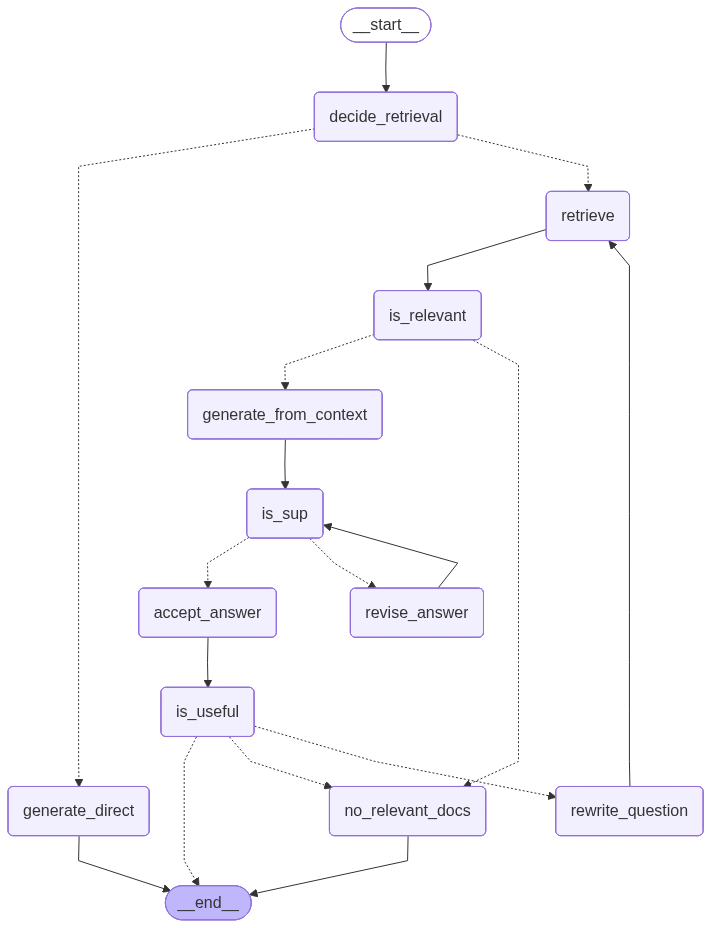

In [48]:
graph=StateGraph(RagState)

graph.add_node("decide_retrieval",decide_retrieval)
graph.add_node("generate_direct",generate_direct)
graph.add_node("retrieve",retrieve)
graph.add_node("is_relevant",is_relevant)
graph.add_node("generate_from_context",generate_from_context)
graph.add_node("no_relevant_docs",no_relevant_docs)
graph.add_node("is_sup",is_sup)
graph.add_node("revise_answer",revise_answer)
graph.add_node("accept_answer",accept_answer)
graph.add_node("is_useful",is_useful)
graph.add_node("rewrite_question",rewrite_question)


graph.add_edge(START,"decide_retrieval")
graph.add_conditional_edges("decide_retrieval",to_retrieve)
graph.add_edge("generate_direct",END)
graph.add_edge("retrieve","is_relevant")
graph.add_conditional_edges("is_relevant",route_after_relevance)
graph.add_edge("no_relevant_docs",END)
graph.add_edge("generate_from_context","is_sup")
graph.add_conditional_edges("is_sup",route_after_issup)

graph.add_edge("revise_answer", "is_sup")  # 🔁 loop back to verify
graph.add_edge("accept_answer", "is_useful")
graph.add_conditional_edges("is_useful", route_after_isuseful)
graph.add_edge("rewrite_question", "retrieve")

app=graph.compile()
app

In [37]:
result = app.invoke(
    {
        'query':'who is CEO of NexaAI',
        'docs':[],
        'answer':"",
        'relevant_docs':[],
        'context':'',
        'answer':''
    }
)

In [38]:
print("need_retrieval:", result.get("need_retrieval"))
print("#docs:", len(result.get("docs", [])))
print("#relevant_docs:", len(result.get("relevant_docs", [])))
print("issup:", result.get("is_support"))
print("evidence:", result.get("evidence"))
print("answer:", result.get("answer"))

need_retrieval: True
#docs: 4
#relevant_docs: 1
issup: fully_supported
evidence: ['Aarav Mehta – CEO & Founder']
answer: Aarav Mehta is the CEO of NexaAI.


In [66]:
for doc in result['docs']:
    print(doc.page_content)
    print("*"*100)


Sick Leave: 10 working days per year

Casual Leave: 6 working days per year

Maternity Leave: As per statutory norms

Unused annual leave may be carried forward up to 30 days
Workplace Conduct
Employees are expected to act professionally and ethically at all times.

Maintain confidentiality of company and client information

Avoid conflicts of interest

No acceptance of bribes or unethical gifts

Compliance with information security policies
Disciplinary Actions
Any violation of company policies may result in disciplinary action.
****************************************************************************************************
NexaAI Solutions – Company Policies
HR Policies
NexaAI is committed to maintaining a fair, inclusive, and performance-driven workplace.
All employment decisions are made without discrimination.

Equal opportunity employer

Bi-annual performance reviews

Clear career progression framework

Strict anti-harassment policy
Leave Policy
Employees are enc

In [85]:
for doc in result['relevant_docs']:
    print(doc.page_content)
    print("*"*100)

NexaAI Solutions – Company Policies
HR Policies
NexaAI is committed to maintaining a fair, inclusive, and performance-driven workplace.
All employment decisions are made without discrimination.

Equal opportunity employer

Bi-annual performance reviews

Clear career progression framework

Strict anti-harassment policy
Leave Policy
Employees are encouraged to maintain a healthy work-life balance.

Annual Leave: 18 working days per year

Sick Leave: 10 working days per year

Casual Leave: 6 working days per year

Maternity Leave: As per statutory norms

****************************************************************************************************
